# Advanced Segmentation Method (Mean Shift)

### Setup & libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# connect Google Drive
drive.mount('/content/drive')

# defining paths
base_path = '/content/drive/MyDrive/EWS-Dataset'
train_path = os.path.join(base_path, 'train')

Mounted at /content/drive


### Help function to load images
Loads the Original picture & the corresponding ground-truth-mask

In [2]:

def load_image_and_mask(folder_path, index=0):  # index of img
    # find all normal pictures (no mask)
    image_files = sorted([f for f in os.listdir(folder_path) if not f.endswith('mask.png') and f.endswith(('.jpg', '.png'))])

    img_name = image_files[index]
    img_path = os.path.join(folder_path, img_name)

    # mask img
    mask_name = img_name.rsplit('.', 1)[0] + '_mask.png'
    mask_path = os.path.join(folder_path, mask_name)

    # load img (BGR to RGB for the original img)
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    # load mask (grayscale, because its only black & white)
    true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    # make the mask binary(0/1)
    _, true_mask = cv2.threshold(true_mask, 127, 1, cv2.THRESH_BINARY)
    # invert mask -> Wheat=1; soil=0
    true_mask = 1- true_mask

    return img_rgb, true_mask, img_name

# testing
test_img, test_true_mask, img_name = load_image_and_mask(train_path, index=10)
print(f"Img loaded: {img_name}")

Img loaded: FPWW0220032_RGB1_20180411_113950_6.png


## Advanced Segmentation Methods

#### Watershed

In [3]:
def segment_wheat_watershed(image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    # rough mask for start
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    rough_mask = cv2.inRange(hsv, np.array([25, 35, 35]), np.array([95, 255, 255]))

    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(rough_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # sure background (via dilation)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # sure foreground (via distance transform)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.15 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(sure_bg, sure_fg) # unknown region


    # Markers for Watershed
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(image_bgr, markers)

    result = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    result[markers > 1] = 1  # Wheat=1
    return result

#### Superpixel + Classification

In [4]:
from skimage.segmentation import slic
from skimage.filters import threshold_otsu

def segment_wheat_superpixel(image_rgb, n_segments=800, compactness=20):
    segments = slic(image_rgb, n_segments=n_segments, compactness=compactness, sigma=1, start_label=1)

    # image values to 0.0 - 1.0 for index calculation
    img_float = image_rgb.astype(float) / 255.0
    R, G, B = img_float[:, :, 0], img_float[:, :, 1], img_float[:, :, 2]

    ExG = 2 * G - R - B # Excess Green Index (highlights green vegetation & pushes brown soil into negative values)

    result = np.zeros(image_rgb.shape[:2], dtype=np.uint8)
    unique_segments = np.unique(segments)

    mean_exg_values = np.zeros(len(unique_segments)) # list for the average ExG values of each superpixel

    # calculate average ExG for each superpixel
    for i, seg_id in enumerate(unique_segments):
        mean_exg = np.mean(ExG[segments == seg_id])
        mean_exg_values[i] = mean_exg

    # find automatic threshold
    try:
        optimal_threshold = threshold_otsu(mean_exg_values) # threshold_otsu: analyzes all values & mathematically finds the best split point between back- & foreground
    except ValueError:
        optimal_threshold = 0.05 # Fallback value if Otsu fails

    # Classify superpixels
    for i, seg_id in enumerate(unique_segments):
        if mean_exg_values[i] > optimal_threshold:  # if average green value of superpixel is above threshold -> Wheat
            result[segments == seg_id] = 1

    # remove noise
    kernel = np.ones((3, 3), np.uint8)
    result = cv2.morphologyEx(result, cv2.MORPH_OPEN, kernel)
    result = cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel)

    return result

### Evaluation & Visualization
IoU (Intersection over Union metric)

In [5]:
def calculate_iou(mask_true, mask_pred):
    intersection = np.logical_and(mask_true, mask_pred)
    union = np.logical_or(mask_true, mask_pred)

    if np.sum(union) == 0:  # avoid division by 0 if union is empty
        return 0

    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

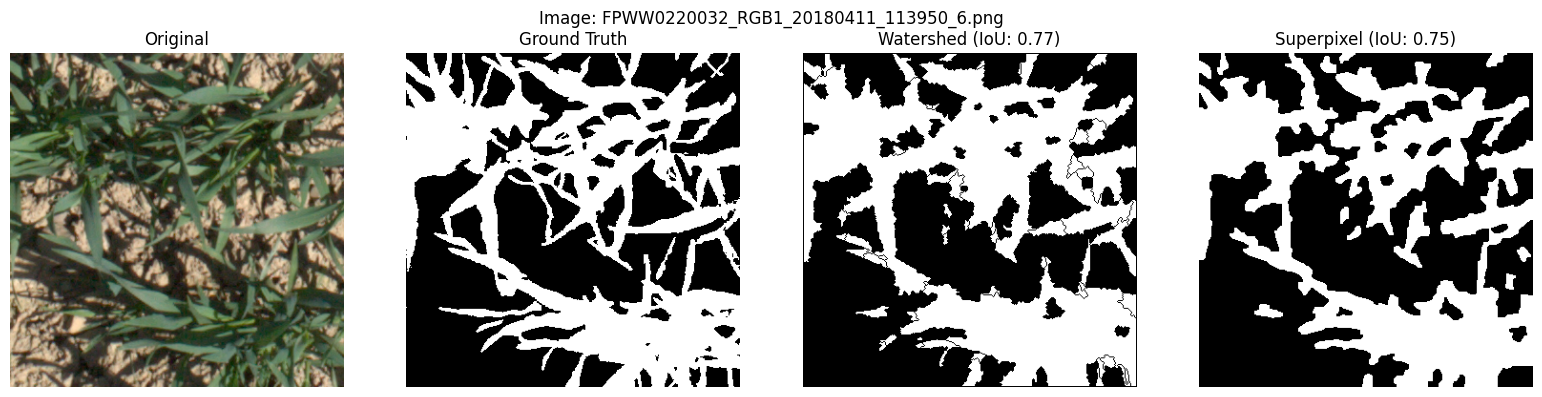

In [6]:
def evaluate_all_methods(folder_path, index=0):
    img, true_mask, name = load_image_and_mask(folder_path, index)

    # generate mask
    m_water = segment_wheat_watershed(img)
    m_super = segment_wheat_superpixel(img)

    # calculate IoUs
    iou_water = calculate_iou(true_mask, m_water)
    iou_super = calculate_iou(true_mask, m_super)

    # plotting
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(true_mask * 255, cmap="gray", vmin=0, vmax=255); ax[1].set_title("Ground Truth"); ax[1].axis("off")
    ax[2].imshow(m_water * 255, cmap="gray", vmin=0, vmax=255); ax[2].set_title(f"Watershed (IoU: {iou_water:.2f})"); ax[2].axis("off")
    ax[3].imshow(m_super * 255, cmap="gray", vmin=0, vmax=255); ax[3].set_title(f"Superpixel (IoU: {iou_super:.2f})"); ax[3].axis("off")

    plt.suptitle(f"Image: {name}"); plt.tight_layout(); plt.show()

# execute
evaluate_all_methods(train_path, index=10)

In [7]:
def test_multiple_images_text(folder_path, indices):
    methods = {
        "Watershed":   segment_wheat_watershed,
        "Superpixel":  segment_wheat_superpixel,
    }
    # collect IoU-values per method
    scores = {name: [] for name in methods}

    print(f"{'img(index)':<10} {'Watershed':>12} {'Superpixel':>12}")
    print("-" * 38)

    for idx in indices:
        image_rgb, true_mask, img_name = load_image_and_mask(folder_path, idx)
        row = f"{idx:<10}"
        for name, fn in methods.items():
            iou = calculate_iou(true_mask, fn(image_rgb))
            scores[name].append(iou)
            row += f"{iou:>12.4f}"
        print(row)

    print("-" * 38)
    avg_row = f"{'Average:':<10}"
    for name in methods:
        avg_row += f"{np.mean(scores[name]):>12.4f}"
    print(avg_row)

# Execute
test_multiple_images_text(train_path, indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

img(index)    Watershed   Superpixel
--------------------------------------
0               0.5968      0.6461
1               0.5071      0.6731
2               0.3200      0.4011
3               0.4732      0.5203
4               0.4451      0.5974
5               0.2194      0.4468
6               0.2712      0.4567
7               0.5570      0.6612
8               0.4198      0.5806
9               0.6915      0.6535
10              0.7691      0.7498
11              0.7792      0.7774
12              0.7615      0.7782
--------------------------------------
Average:        0.5239      0.6109


## Simulation of Distortions


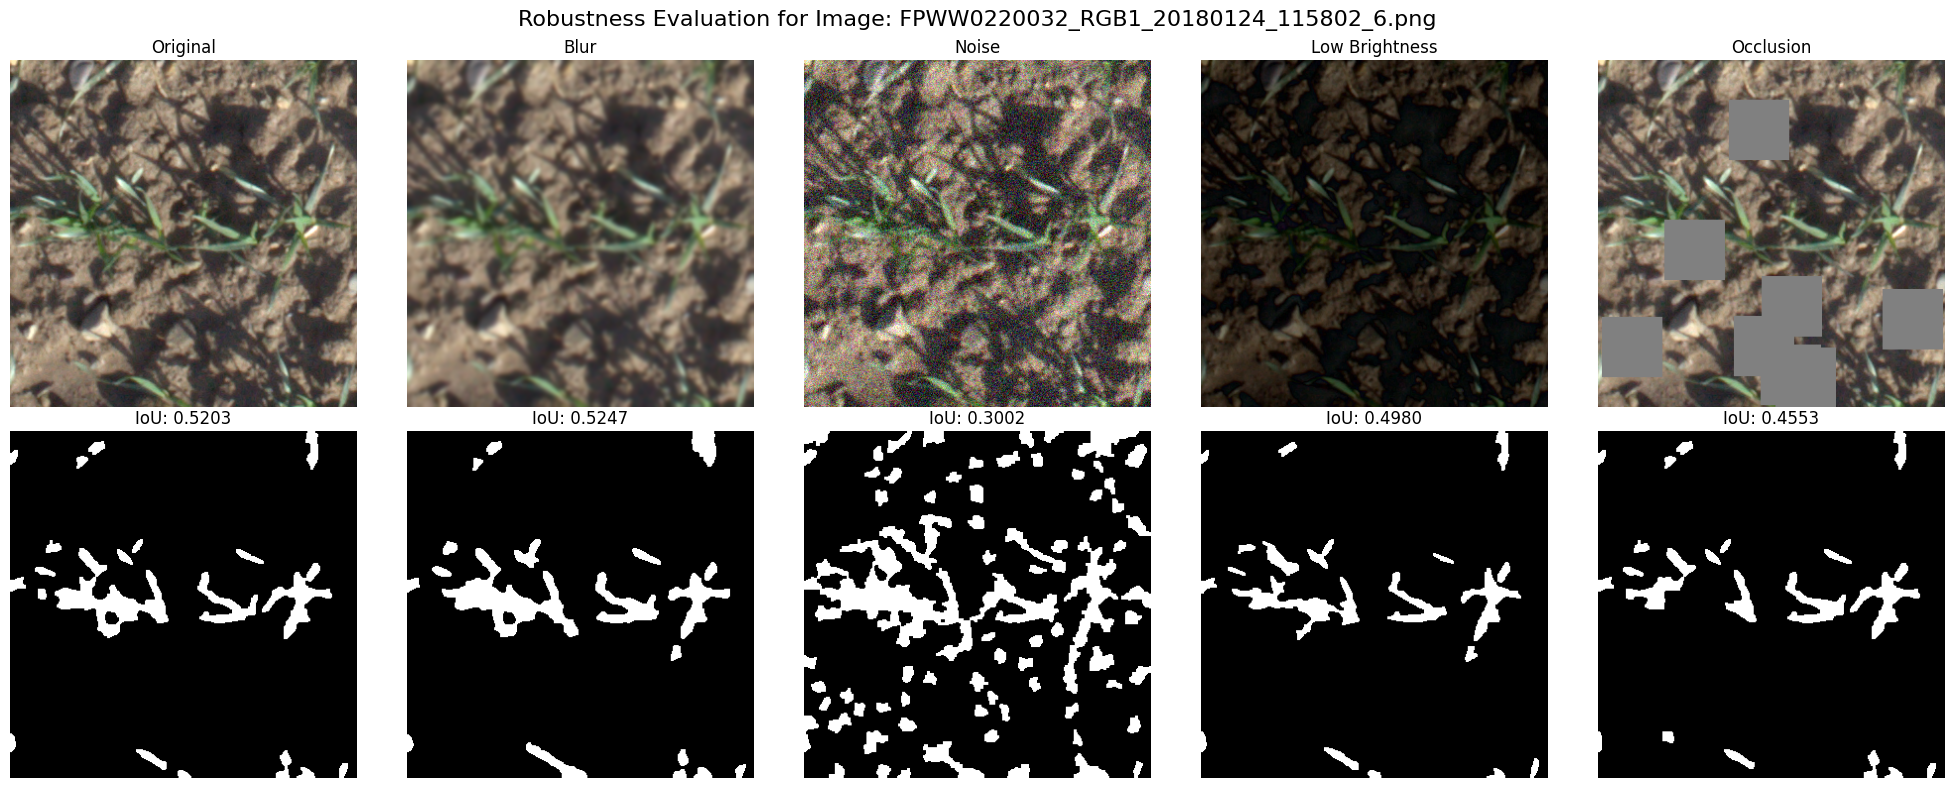

In [8]:
import random

# Distortions:
def add_blur(image, ksize=9): # Gaussian Blur
    return cv2.GaussianBlur(image, (ksize, ksize), 0)

def add_noise(image, mean=0, std=30): # Gaussian Noise
    noise = np.random.normal(mean, std, image.shape).astype(np.float32)
    noisy_image = cv2.add(image.astype(np.float32), noise)
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def adjust_brightness_contrast(image, alpha=0.6, beta=-40): #simulate bad light
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta) #alpha<1 lowers contrast, beta<0 makes img darker

def add_partial_occlusion(image, num_blocks=8, block_size=60):
    occluded = image.copy()
    h, w = occluded.shape[:2]
    for _ in range(num_blocks):
        x = random.randint(0, w - block_size)
        y = random.randint(0, h - block_size)
        cv2.rectangle(occluded, (x, y), (x + block_size, y + block_size), (128, 128, 128), -1) #rectangles as occlusion
    return occluded

# testing:
def evaluate_robustness(folder_path, index=10):
    img_orig, true_mask, name = load_image_and_mask(folder_path, index)

    # distorting
    img_blur = add_blur(img_orig)
    img_noise = add_noise(img_orig)
    img_dark = adjust_brightness_contrast(img_orig)
    img_occ = add_partial_occlusion(img_orig)

    # apply superpixel on all
    mask_orig = segment_wheat_superpixel(img_orig)
    mask_blur = segment_wheat_superpixel(img_blur)
    mask_noise = segment_wheat_superpixel(img_noise)
    mask_dark = segment_wheat_superpixel(img_dark)
    mask_occ = segment_wheat_superpixel(img_occ)

    # ioU
    iou_orig = calculate_iou(true_mask, mask_orig)
    iou_blur = calculate_iou(true_mask, mask_blur)
    iou_noise = calculate_iou(true_mask, mask_noise)
    iou_dark = calculate_iou(true_mask, mask_dark)
    iou_occ = calculate_iou(true_mask, mask_occ)

    # plotting
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))

    images = [img_orig, img_blur, img_noise, img_dark, img_occ]
    masks = [mask_orig, mask_blur, mask_noise, mask_dark, mask_occ]
    ious = [iou_orig, iou_blur, iou_noise, iou_dark, iou_occ]
    titles = ["Original", "Blur", "Noise", "Low Brightness", "Occlusion"]

    for i in range(5):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(titles[i])
        axes[0, i].axis("off")
        axes[1, i].imshow(masks[i] * 255, cmap="gray", vmin=0, vmax=255)
        axes[1, i].set_title(f"IoU: {ious[i]:.4f}")
        axes[1, i].axis("off")

    plt.suptitle(f"Robustness Evaluation for Image: {name}", fontsize=16)
    plt.tight_layout()
    plt.show()

# execute
evaluate_robustness(train_path, index=3)

In [9]:
def evaluate_distortions_batch(folder_path, indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]):
    print(f"{'img(index)':<12} {'Original':<10} {'Blur':<10} {'Noise':<10} {'Dark':<10} {'Occlusion':<10}")
    print("-" * 65)
    # list for average
    ious = {"orig": [], "blur": [], "noise": [], "dark": [], "occ": []}

    for i in indices:
        img_orig, true_mask, name = load_image_and_mask(folder_path, i)

        # distortions
        img_blur = add_blur(img_orig)
        img_noise = add_noise(img_orig)
        img_dark = adjust_brightness_contrast(img_orig)
        img_occ = add_partial_occlusion(img_orig)

        # superpixel
        mask_orig = segment_wheat_superpixel(img_orig)
        mask_blur = segment_wheat_superpixel(img_blur)
        mask_noise = segment_wheat_superpixel(img_noise)
        mask_dark = segment_wheat_superpixel(img_dark)
        mask_occ = segment_wheat_superpixel(img_occ)

        # IoU
        i_orig = calculate_iou(true_mask, mask_orig)
        i_blur = calculate_iou(true_mask, mask_blur)
        i_noise = calculate_iou(true_mask, mask_noise)
        i_dark = calculate_iou(true_mask, mask_dark)
        i_occ = calculate_iou(true_mask, mask_occ)

        # add values to list
        ious["orig"].append(i_orig)
        ious["blur"].append(i_blur)
        ious["noise"].append(i_noise)
        ious["dark"].append(i_dark)
        ious["occ"].append(i_occ)

        print(f"{i:<12} {i_orig:<10.4f} {i_blur:<10.4f} {i_noise:<10.4f} {i_dark:<10.4f} {i_occ:<10.4f}")

    print("-" * 65)

    # calc average
    avg_orig = np.mean(ious["orig"])
    avg_blur = np.mean(ious["blur"])
    avg_noise = np.mean(ious["noise"])
    avg_dark = np.mean(ious["dark"])
    avg_occ = np.mean(ious["occ"])

    print(f"{'Average:':<12} {avg_orig:<10.4f} {avg_blur:<10.4f} {avg_noise:<10.4f} {avg_dark:<10.4f} {avg_occ:<10.4f}")

# execute
evaluate_distortions_batch(train_path, indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

img(index)   Original   Blur       Noise      Dark       Occlusion 
-----------------------------------------------------------------
0            0.6461     0.6331     0.5578     0.6683     0.5353    
1            0.6731     0.6433     0.2755     0.6800     0.3854    
2            0.4011     0.4782     0.1649     0.1989     0.3960    
3            0.5203     0.5247     0.2802     0.4980     0.4765    
4            0.5974     0.5930     0.2929     0.6092     0.4960    
5            0.4468     0.4456     0.2618     0.4638     0.3741    
6            0.4567     0.4566     0.1844     0.4175     0.3799    
7            0.6612     0.6576     0.5697     0.6792     0.4863    
8            0.5806     0.5702     0.3853     0.5934     0.4285    
9            0.6535     0.6597     0.5829     0.4872     0.5384    
10           0.7498     0.7461     0.6526     0.5115     0.6069    
11           0.7774     0.7788     0.6615     0.4695     0.5955    
12           0.7782     0.7672     0.6699     0.49

### improving robustness of noise

In [10]:
def segment_wheat_superpixel_noise_robust(image_rgb, n_segments=800, compactness=20):
    """
    Superpixel variant, specifically robust against noise.

    Core idea: Noise primarily disrupts pixel-wise ExG values.
    Solution: Strong edge-preserving denoising BEFORE SLIC and before ExG calculation.
      1. Bilateral Filter (edge-preserving, removes high-frequency noise)
      2. Additional Median Filter (robust against salt-and-pepper noise)
      3. Standard ExG + Otsu as in the original
    """

    # double denoising
    # Bilateral: removes Gaussian noise, preserves edges
    denoised = cv2.bilateralFilter(image_rgb, d=9, sigmaColor=75, sigmaSpace=75)
    # Median: additional smoothing, very effective against isolated outliers
    denoised = cv2.medianBlur(denoised, 5)

    # SLIC
    segments = slic(denoised, n_segments=n_segments,
                    compactness=compactness, sigma=1, start_label=1)

    # ExG calculation
    img_float = denoised.astype(float) / 255.0
    R, G, B = img_float[:, :, 0], img_float[:, :, 1], img_float[:, :, 2]
    ExG = 2 * G - R - B

    # per-superpixel mean + Otsu
    unique_segments = np.unique(segments)
    mean_exg_values = np.zeros(len(unique_segments))
    for i, seg_id in enumerate(unique_segments):
        mean_exg_values[i] = np.mean(ExG[segments == seg_id])

    try:
        optimal_threshold = threshold_otsu(mean_exg_values)
    except ValueError:
        optimal_threshold = 0.05

    # classification + Morphology
    result = np.zeros(image_rgb.shape[:2], dtype=np.uint8)
    for i, seg_id in enumerate(unique_segments):
        if mean_exg_values[i] > optimal_threshold:
            result[segments == seg_id] = 1

    kernel = np.ones((3, 3), np.uint8)
    result = cv2.morphologyEx(result, cv2.MORPH_OPEN, kernel)
    result = cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel)

    return result

In [11]:
def evaluate_noise_robustness(folder_path, indices):

    print(f"{'img':<6} {'method':<28} {'Original':>10} {'Noise':>10}")
    print("=" * 60)

    scores_orig   = {'Original': [], 'Noise': []}
    scores_robust = {'Original': [], 'Noise': []}

    for idx in indices:
        img_orig, true_mask, _ = load_image_and_mask(folder_path, idx)
        img_noise = add_noise(img_orig)

        iou_o_orig  = calculate_iou(true_mask, segment_wheat_superpixel(img_orig))
        iou_o_noise = calculate_iou(true_mask, segment_wheat_superpixel(img_noise))
        iou_r_orig  = calculate_iou(true_mask, segment_wheat_superpixel_noise_robust(img_orig))
        iou_r_noise = calculate_iou(true_mask, segment_wheat_superpixel_noise_robust(img_noise))

        scores_orig['Original'].append(iou_o_orig)
        scores_orig['Noise'].append(iou_o_noise)
        scores_robust['Original'].append(iou_r_orig)
        scores_robust['Noise'].append(iou_r_noise)

        print(f"{idx:<6} {'Superpixel':<28}{iou_o_orig:>10.4f}{iou_o_noise:>10.4f}")
        print(f"{'':<6} {'Superpixel_noise_robust':<28}{iou_r_orig:>10.4f}{iou_r_noise:>10.4f}")
        print("-" * 60)

    print("\n" + "=" * 60)
    print(f"{'AVG':<6} {'method':<28} {'Original':>10} {'Noise':>10}")
    print("-" * 60)
    print(f"{'':<6} {'Superpixel':<28}"
          f"{np.mean(scores_orig['Original']):>10.4f}{np.mean(scores_orig['Noise']):>10.4f}")
    print(f"{'':<6} {'Superpixel_noise_robust':<28}"
          f"{np.mean(scores_robust['Original']):>10.4f}{np.mean(scores_robust['Noise']):>10.4f}")
    diff_orig  = np.mean(scores_robust['Original']) - np.mean(scores_orig['Original'])
    diff_noise = np.mean(scores_robust['Noise'])    - np.mean(scores_orig['Noise'])
    print(f"{'':<6} {'Δ (robust-orig)':<28}{diff_orig:>+10.4f}{diff_noise:>+10.4f}")

# Execute
evaluate_noise_robustness(train_path, indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

img    method                         Original      Noise
0      Superpixel                      0.6461    0.5920
       Superpixel_noise_robust         0.6333    0.6153
------------------------------------------------------------
1      Superpixel                      0.6731    0.2202
       Superpixel_noise_robust         0.6355    0.5746
------------------------------------------------------------
2      Superpixel                      0.4011    0.1614
       Superpixel_noise_robust         0.4992    0.3573
------------------------------------------------------------
3      Superpixel                      0.5203    0.3313
       Superpixel_noise_robust         0.5104    0.4670
------------------------------------------------------------
4      Superpixel                      0.5974    0.2988
       Superpixel_noise_robust         0.5857    0.5017
------------------------------------------------------------
5      Superpixel                      0.4468    0.2552
       Superpixel_noi